# Attribution Analysis by Prediction Correctness

This notebook analyzes how feature attributions differ between correct and incorrect predictions:

1. **Correct vs Incorrect**: Compare attribution patterns when the model predicts correctly vs incorrectly
2. **By Activity + Correctness**: Break down by predicted activity, then by correctness
3. **Confidence Analysis**: How attributions relate to model confidence
4. **Feature Importance Shifts**: Which features matter more for correct/incorrect predictions
5. **Error Pattern Analysis**: What patterns appear in misclassified samples

## 1. Setup

In [1]:
# Path setup and config import
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

from src.interpretability.config.bpic17_config import CONFIG
print(f"Dataset: {CONFIG.dataset_name}")

Dataset: BPIC17


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from collections import defaultdict
import pickle
import random
from scipy import stats

from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Reproducibility
SEED = CONFIG.seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = Evaluation(
    model=model,
    dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    all_cat=CONFIG.all_cat,
    all_num=CONFIG.all_num
)

tool = InterpretabilityTool(model, model.data_set_categories, device=device)

# Get activity mapping
cat_categories, num_categories = model.data_set_categories
activity_info = cat_categories[0]  # First categorical is Activity
activity_mapping = activity_info[2]  # Index 2 is the mapping dict
idx_to_activity = {v: k for k, v in activity_mapping.items()}

print(f"Loaded {len(test_dataset)} samples")
print(f"Available cases: {len(eval_helper.cases)}")
print(f"Activities: {len(activity_mapping)}")

Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('Action', 7, {'Created': 1, 'Deleted': 2, 'EOS': 3, 'Obtained': 4, 'Released': 5, 'statechange': 6}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'User_109': 13, 'User_11': 14, 'User_110': 15, 'U

Loaded 253196 samples
Available cases: 6301
Activities: 27


## 2. Configuration

In [4]:
# ============================================================
# CONFIGURATION
# ============================================================
TEST_MODE = True          # Set to False for full dataset analysis
TEST_SAMPLE_SIZE = 100    # Number of samples in test mode
IG_STEPS = 30             # Integration steps
TARGET = CONFIG.concept_name  # Attribution target (Activity)

# Get all input features
ALL_CAT_FEATURES = [name for name, _, _ in cat_categories]
ALL_NUM_FEATURES = [name for name, _, _ in num_categories]
ALL_FEATURES = ALL_CAT_FEATURES + ALL_NUM_FEATURES

print(f"Mode: {'TEST' if TEST_MODE else 'FULL'}")
print(f"Sample size: {TEST_SAMPLE_SIZE if TEST_MODE else 'ALL'}")
print(f"Features: {len(ALL_FEATURES)} ({len(ALL_CAT_FEATURES)} cat, {len(ALL_NUM_FEATURES)} num)")

Mode: TEST
Sample size: 100
Features: 18 (9 cat, 9 num)


## 3. Collect Samples and Compute Predictions + Attributions

In [5]:
# Collect all prefix-suffix pairs with ground truth
all_samples = []

# Get EOS index for proper handling
eos_idx = activity_mapping.get('EOS', activity_mapping.get('<EOS>', None))
print(f"EOS index: {eos_idx}")
print(f"Activity mapping sample: {list(activity_mapping.items())[:5]}")

for case_name, full_case in tqdm(eval_helper.cases.items(), desc="Collecting samples"):
    for prefix_len, prefix, suffix in eval_helper._iterate_case(full_case):
        if prefix_len >= 1:  # At least 1 event
            # Get ground truth (first event in suffix)
            suffix_cats, suffix_nums = suffix
            
            # Check if suffix is empty - no more events to predict
            if suffix_cats[0].numel() == 0:
                ground_truth = 'EOS'
                ground_truth_idx = eos_idx if eos_idx is not None else 0
            else:
                ground_truth_idx = suffix_cats[0][0, 0].item()
                
                # Check if the actual next event IS the EOS token
                # (NOT padding - padding index 0 is different from EOS)
                if eos_idx is not None and ground_truth_idx == eos_idx:
                    ground_truth = 'EOS'
                else:
                    ground_truth = idx_to_activity.get(ground_truth_idx, f"Unknown_{ground_truth_idx}")
            
            all_samples.append({
                'case_name': case_name,
                'prefix_len': prefix_len,
                'prefix': prefix,
                'suffix': suffix,
                'ground_truth': ground_truth,
                'ground_truth_idx': ground_truth_idx
            })

print(f"Total samples: {len(all_samples)}")

# Sample if in test mode
if TEST_MODE:
    samples = random.sample(all_samples, min(TEST_SAMPLE_SIZE, len(all_samples)))
else:
    samples = all_samples
print(f"Using {len(samples)} samples")

# Show ground truth distribution
gt_counts = pd.Series([s['ground_truth'] for s in all_samples]).value_counts()
print(f"\nGround truth distribution (all samples):")
print(gt_counts)

# Count EOS ground truths
eos_count = sum(1 for s in all_samples if s['ground_truth'] == 'EOS')
print(f"\nEOS as ground truth: {eos_count} samples ({100*eos_count/len(all_samples):.1f}%)")

EOS index: 11
Activity mapping sample: [('A_Accepted', 1), ('A_Cancelled', 2), ('A_Complete', 3), ('A_Concept', 4), ('A_Create Application', 5)]


Total samples: 233080
Using 100 samples

Ground truth distribution (all samples):
W_Validate application      41630
W_Call after offers         38233
W_Call incomplete files     33579
W_Complete application      29628
W_Handle leads               9267
O_Created                    8602
O_Create Offer               8595
O_Sent (mail and online)     7947
A_Validating                 7661
A_Accepted                   6256
A_Complete                   6245
A_Concept                    6242
O_Returned                   4613
A_Incomplete                 4522
O_Cancelled                  4265
A_Submitted                  4020
O_Accepted                   3406
A_Pending                    3406
A_Cancelled                  2118
O_Refused                     950
A_Denied                      755
W_Assess potential fraud      661
O_Sent (online only)          414
W_Shortened completion         65
Name: count, dtype: int64

EOS as ground truth: 0 samples (0.0%)


In [6]:
# Compute predictions and attributions for all samples
results = []

# Helper to normalize activity names for comparison (handle EOS variants)
def normalize_activity(name):
    """Normalize activity name for comparison."""
    if name in ['EOS', '<EOS>', 'eos', '<eos>']:
        return 'EOS'
    return name

for sample in tqdm(samples, desc="Computing predictions & attributions"):
    try:
        prefix = sample['prefix']
        prefix_len = sample['prefix_len']
        
        # Convert prefix for model
        cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
        num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
        process = (cat_tensors, num_tensors)
        
        # Compute attribution (this also gives us the prediction)
        attr_map = tool.compute_attribution_map(
            process=process,
            prefix_length=prefix_len,
            target=TARGET,
            target_class='auto',  # Uses predicted class
            method='integrated_gradients',
            n_steps=IG_STEPS
        )
        
        # Extract predicted activity from target description
        # Format: "Activity=Resolve ticket (idx=X)"
        pred_activity = attr_map.target_description.split('=')[1].split('(')[0].strip() if '=' in attr_map.target_description else 'Unknown'
        
        # Get prediction confidence (softmax probability)
        # We need to run the model to get logits
        with torch.no_grad():
            cat_input = tuple(t.unsqueeze(0) for t in cat_tensors)
            num_input = tuple(t.unsqueeze(0) for t in num_tensors)
            
            # Prepare prefixes and suffixes
            suffix_split = model.seq_len_pred
            prefixes_cat = [cat[:, :-suffix_split] for cat in cat_input]
            prefixes_num = [num[:, :-suffix_split] for num in num_input]
            suffixes_cat = [cat[:, -suffix_split:] for cat in cat_input]
            suffixes_num = [num[:, -suffix_split:] for num in num_input]
            
            output, _, _, _ = model(
                prefixes=[prefixes_cat, prefixes_num],
                suffixes=[suffixes_cat, suffixes_num],
                teacher_forcing_ratio=0.0
            )
            
            cat_preds, num_preds = output
            logits = cat_preds[f'{TARGET}_mean'][0, 0, :]  # First step, first batch
            probs = torch.softmax(logits, dim=-1)
            pred_idx = probs.argmax().item()
            confidence = probs[pred_idx].item()
        
        # Check correctness with normalized activity names
        pred_normalized = normalize_activity(pred_activity)
        gt_normalized = normalize_activity(sample['ground_truth'])
        is_correct = (pred_normalized == gt_normalized)
        
        # Extract feature attributions
        feature_attrs = {}
        for feat in attr_map.feature_names:
            if feat in attr_map.attributions:
                vals = attr_map.attributions[feat]
                if hasattr(vals, 'detach'):
                    vals = vals.detach().cpu().numpy()
                feature_attrs[feat] = np.abs(vals).sum()  # Total absolute attribution
        
        results.append({
            'case_name': sample['case_name'],
            'prefix_len': prefix_len,
            'ground_truth': sample['ground_truth'],
            'predicted': pred_activity,
            'is_correct': is_correct,
            'confidence': confidence,
            **feature_attrs
        })
        
    except Exception as e:
        print(f"Error for {sample['case_name']}: {e}")

df = pd.DataFrame(results)
print(f"\nComputed {len(df)} results")
print(f"Correct: {df['is_correct'].sum()} ({100*df['is_correct'].mean():.1f}%)")
print(f"Incorrect: {(~df['is_correct']).sum()} ({100*(~df['is_correct']).mean():.1f}%)")

# Show prediction vs ground truth for EOS cases
eos_cases = df[(df['ground_truth'] == 'EOS') | (df['predicted'].str.contains('EOS', case=False, na=False))]
if len(eos_cases) > 0:
    print(f"\nEOS-related predictions: {len(eos_cases)}")
    print(eos_cases[['ground_truth', 'predicted', 'is_correct']].value_counts())

Computing predictions & attributions:   0%|          | 0/100 [00:00<?, ?it/s]


Computed 100 results
Correct: 78 (78.0%)
Incorrect: 22 (22.0%)


## 4. Attribution Comparison: Correct vs Incorrect Predictions

In [7]:
# Compute statistics for correct vs incorrect
available_features = [f for f in ALL_FEATURES if f in df.columns]

correct_df = df[df['is_correct']]
incorrect_df = df[~df['is_correct']]

print("="*80)
print("ATTRIBUTION COMPARISON: CORRECT vs INCORRECT PREDICTIONS")
print("="*80)
print(f"\nCorrect predictions: {len(correct_df)}")
print(f"Incorrect predictions: {len(incorrect_df)}")

comparison_data = []
for feat in available_features:
    correct_mean = correct_df[feat].mean() if len(correct_df) > 0 else 0
    correct_std = correct_df[feat].std() if len(correct_df) > 0 else 0
    incorrect_mean = incorrect_df[feat].mean() if len(incorrect_df) > 0 else 0
    incorrect_std = incorrect_df[feat].std() if len(incorrect_df) > 0 else 0
    
    # Statistical test
    if len(correct_df) > 1 and len(incorrect_df) > 1:
        t_stat, p_value = stats.ttest_ind(correct_df[feat].dropna(), incorrect_df[feat].dropna())
    else:
        t_stat, p_value = 0, 1.0
    
    comparison_data.append({
        'Feature': feat,
        'Correct_Mean': correct_mean,
        'Correct_Std': correct_std,
        'Incorrect_Mean': incorrect_mean,
        'Incorrect_Std': incorrect_std,
        'Difference': incorrect_mean - correct_mean,
        'Ratio': incorrect_mean / correct_mean if correct_mean > 0 else np.nan,
        'P_Value': p_value,
        'Significant': p_value < 0.05
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

ATTRIBUTION COMPARISON: CORRECT vs INCORRECT PREDICTIONS

Correct predictions: 78
Incorrect predictions: 22

              Feature  Correct_Mean  Correct_Std  Incorrect_Mean  Incorrect_Std  Difference    Ratio  P_Value  Significant
         concept:name      1.917291     0.894146        1.941569       0.753586    0.024278 1.012663 0.907780        False
               Action      0.475058     0.313321        0.344576       0.285112   -0.130482 0.725334 0.081901        False
         org:resource      0.733472     0.223778        0.672179       0.235952   -0.061293 0.916435 0.264913        False
          EventOrigin      0.550190     0.496361        0.406332       0.403426   -0.143858 0.738531 0.215449        False
 lifecycle:transition      1.228063     0.528192        1.118623       0.327679   -0.109440 0.910884 0.359228        False
        case:LoanGoal      0.105765     0.074770        0.093343       0.089043   -0.012423 0.882546 0.511231        False
 case:ApplicationType      0.1

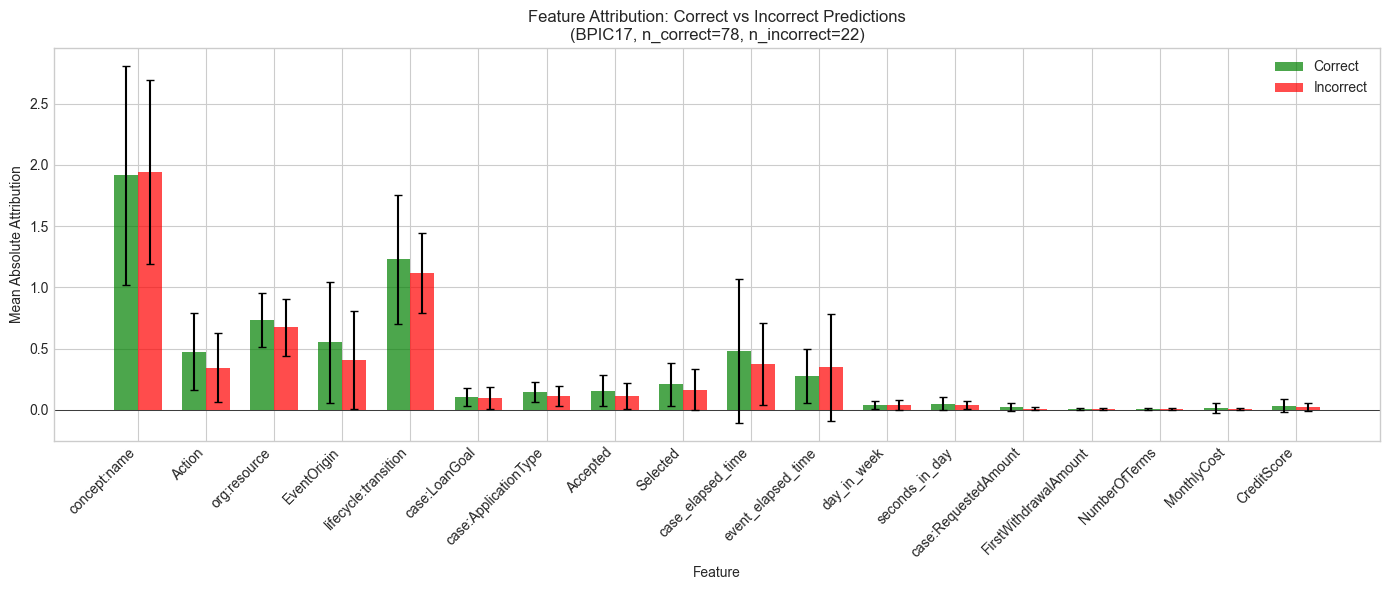


* indicates statistically significant difference (p < 0.05)


In [8]:
# Visualization 1: Side-by-side bar chart
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(available_features))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Correct_Mean'], width, 
               yerr=comparison_df['Correct_Std'], label='Correct', 
               color='green', alpha=0.7, capsize=3)
bars2 = ax.bar(x + width/2, comparison_df['Incorrect_Mean'], width,
               yerr=comparison_df['Incorrect_Std'], label='Incorrect', 
               color='red', alpha=0.7, capsize=3)

# Mark significant differences
for i, (idx, row) in enumerate(comparison_df.iterrows()):
    if row['Significant']:
        max_val = max(row['Correct_Mean'], row['Incorrect_Mean'])
        ax.annotate('*', (i, max_val + 0.02), ha='center', fontsize=14, fontweight='bold')

ax.set_ylabel('Mean Absolute Attribution')
ax.set_xlabel('Feature')
ax.set_title(f'Feature Attribution: Correct vs Incorrect Predictions\n({CONFIG.dataset_name}, n_correct={len(correct_df)}, n_incorrect={len(incorrect_df)})')
ax.set_xticks(x)
ax.set_xticklabels(available_features, rotation=45, ha='right')
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\n* indicates statistically significant difference (p < 0.05)")

/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_12344/2235707387.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Correct', 'Incorrect'], patch_artist=True)
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_12344/2235707387.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Correct', 'Incorrect'], patch_artist=True)
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_12344/2235707387.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Correct', 'Incorrect'], patch_artis

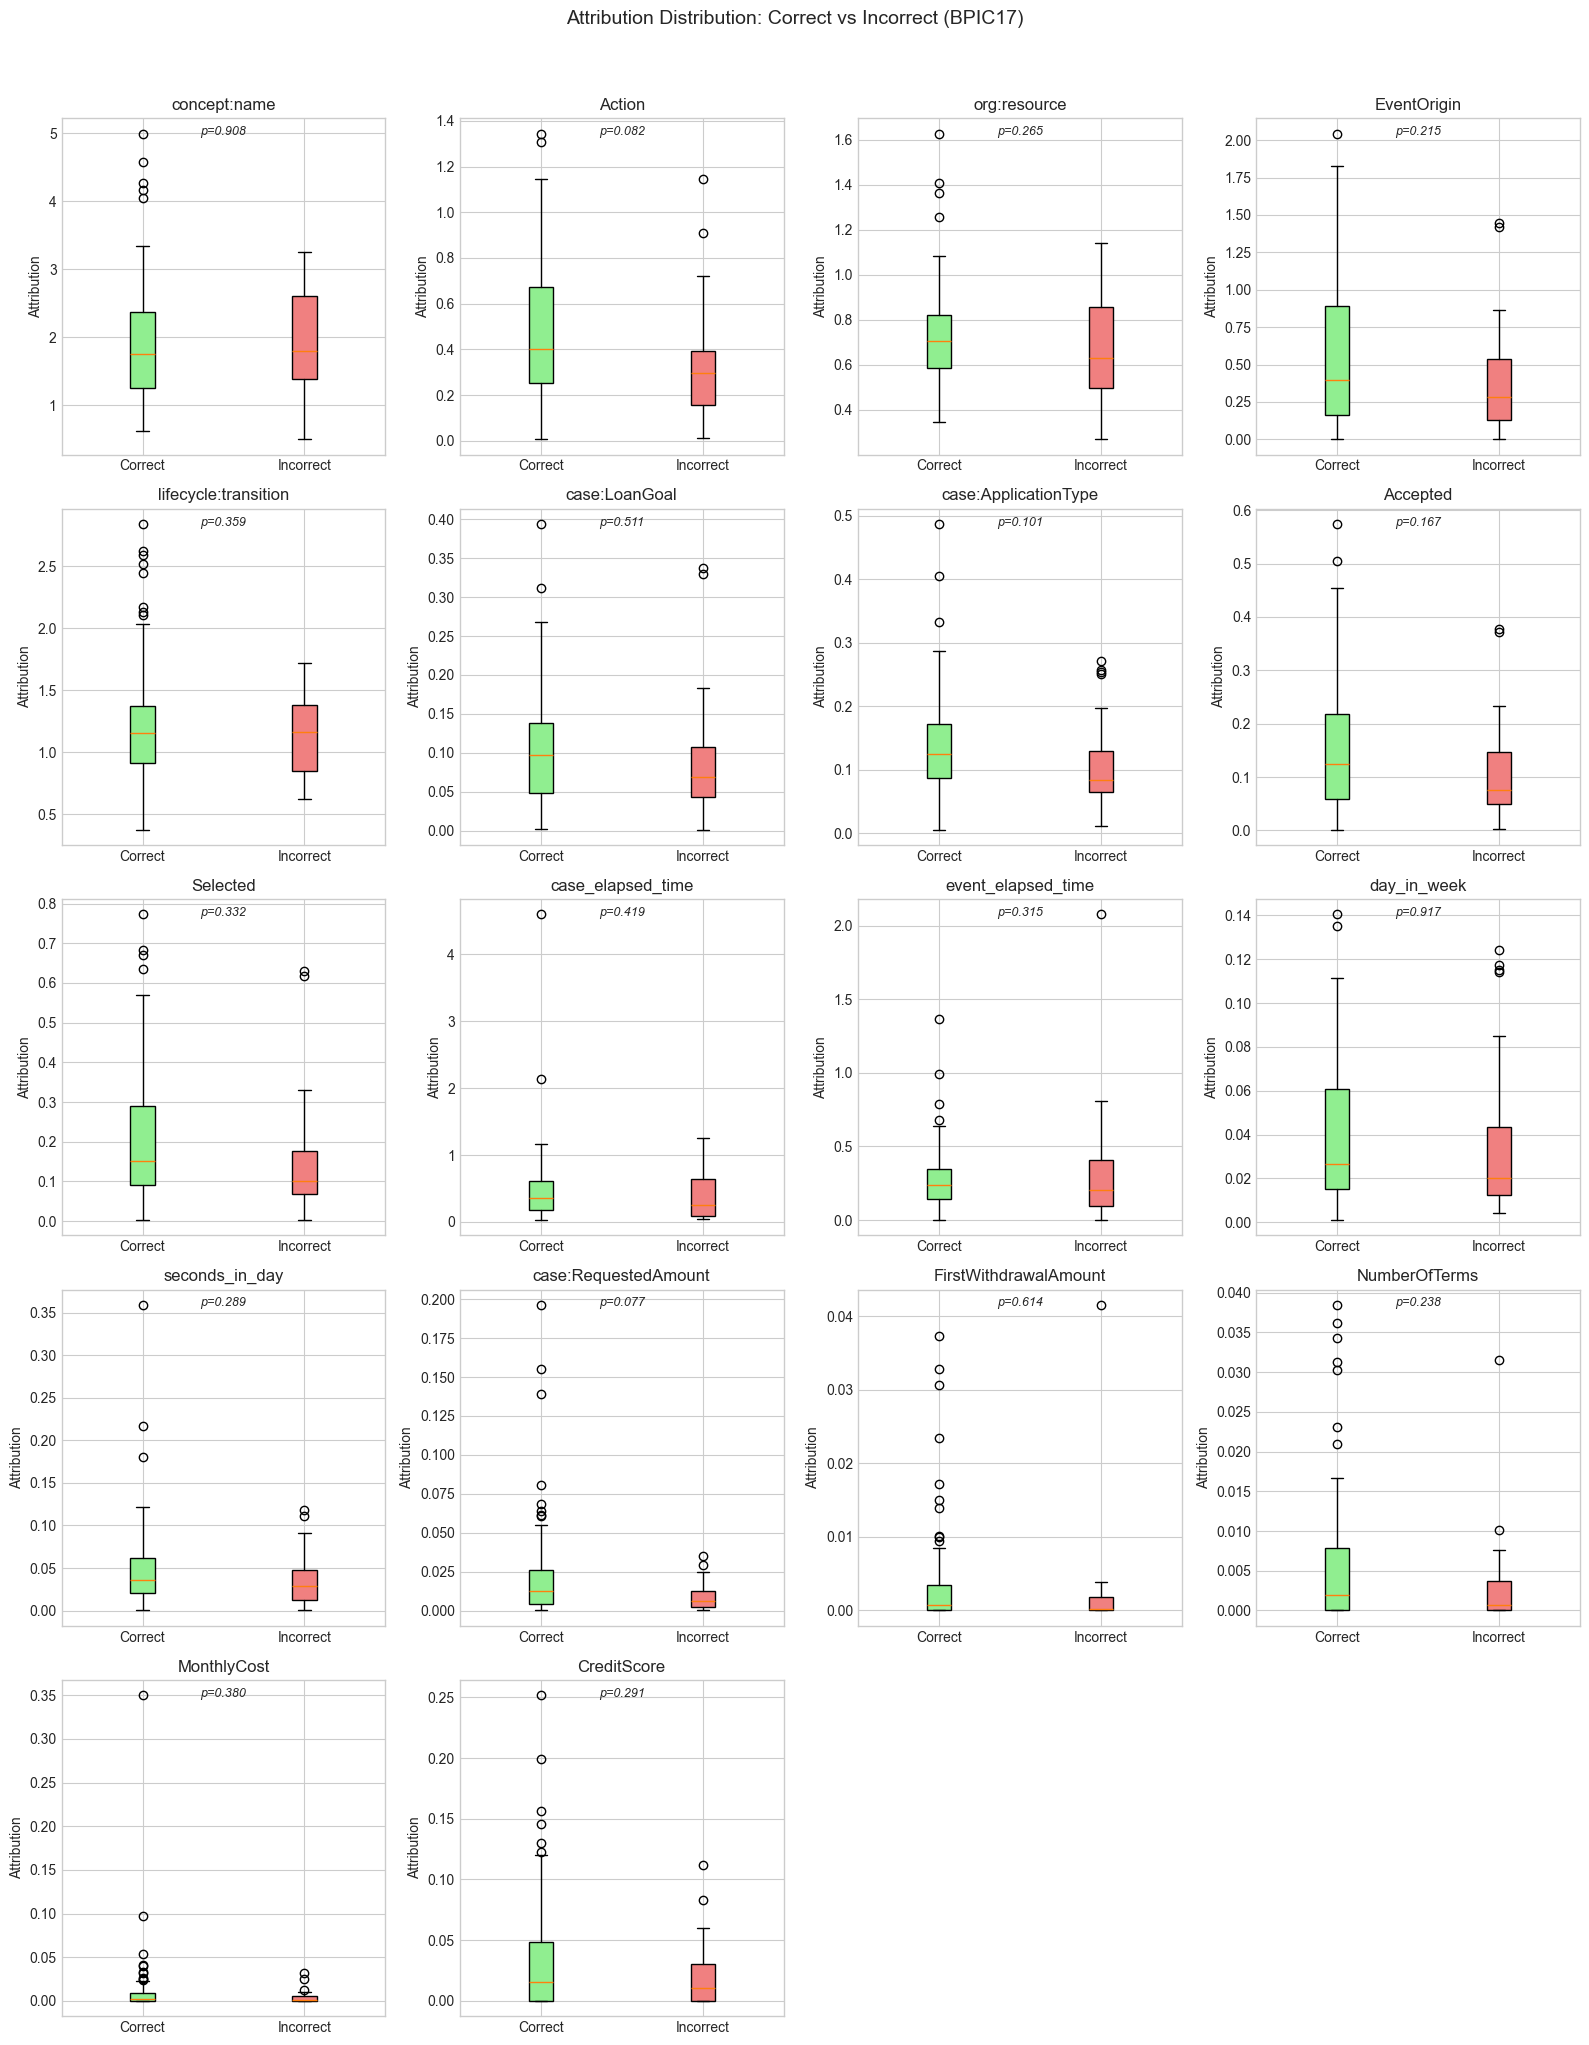

In [9]:
# Visualization 2: Box plots for correct vs incorrect
n_features = len(available_features)
n_cols = min(4, n_features)
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, feat in enumerate(available_features):
    ax = axes[idx]
    
    data_to_plot = [
        correct_df[feat].dropna().values,
        incorrect_df[feat].dropna().values
    ]
    
    bp = ax.boxplot(data_to_plot, labels=['Correct', 'Incorrect'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightgreen')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    ax.set_title(feat)
    ax.set_ylabel('Attribution')
    
    # Add p-value annotation
    p_val = comparison_df[comparison_df['Feature'] == feat]['P_Value'].values[0]
    sig_text = f'p={p_val:.3f}' + (' *' if p_val < 0.05 else '')
    ax.annotate(sig_text, xy=(0.5, 0.95), xycoords='axes fraction', 
                ha='center', fontsize=9, style='italic')

# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Attribution Distribution: Correct vs Incorrect ({CONFIG.dataset_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

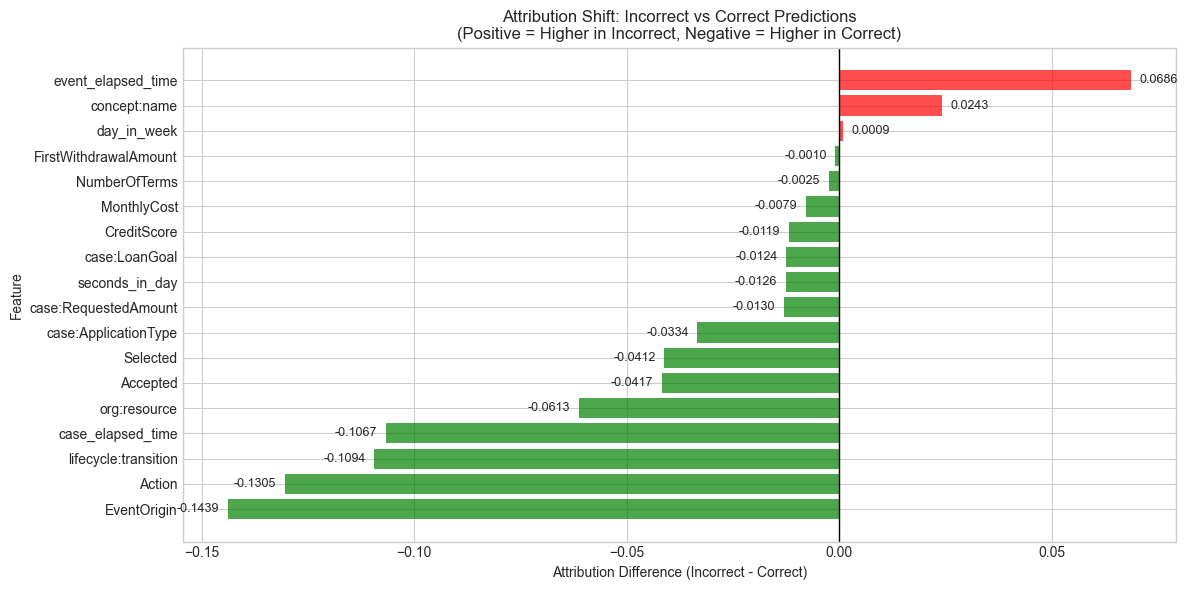

In [10]:
# Visualization 3: Attribution difference (Incorrect - Correct)
fig, ax = plt.subplots(figsize=(12, 6))

# Sort by difference
sorted_comparison = comparison_df.sort_values('Difference', ascending=True)
colors = ['red' if d > 0 else 'green' for d in sorted_comparison['Difference']]

bars = ax.barh(sorted_comparison['Feature'], sorted_comparison['Difference'], color=colors, alpha=0.7)

ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Attribution Difference (Incorrect - Correct)')
ax.set_ylabel('Feature')
ax.set_title(f'Attribution Shift: Incorrect vs Correct Predictions\n(Positive = Higher in Incorrect, Negative = Higher in Correct)')

# Add value labels
for bar, val in zip(bars, sorted_comparison['Difference']):
    x_pos = val + 0.002 if val >= 0 else val - 0.002
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
            va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.show()

## 5. Attribution by Predicted Activity + Correctness

In [11]:
# Get activities with enough samples in both correct and incorrect
activity_stats = df.groupby('predicted').agg({
    'is_correct': ['sum', 'count', 'mean']
}).reset_index()
activity_stats.columns = ['Activity', 'Correct', 'Total', 'Accuracy']
activity_stats['Incorrect'] = activity_stats['Total'] - activity_stats['Correct']
activity_stats = activity_stats.sort_values('Total', ascending=False)

print("Prediction Statistics by Activity:")
print(activity_stats.to_string(index=False))

Prediction Statistics by Activity:
               Activity  Correct  Total  Accuracy  Incorrect
 W_Validate application       17     24  0.708333          7
    W_Call after offers       18     22  0.818182          4
 W_Complete application       13     18  0.722222          5
W_Call incomplete files       14     16  0.875000          2
              A_Concept        4      4  1.000000          0
         W_Handle leads        3      4  0.750000          1
           A_Validating        3      3  1.000000          0
                 O_Sent        0      3  0.000000          3
           A_Incomplete        2      2  1.000000          0
              O_Created        2      2  1.000000          0
             A_Complete        1      1  1.000000          0
             O_Returned        1      1  1.000000          0


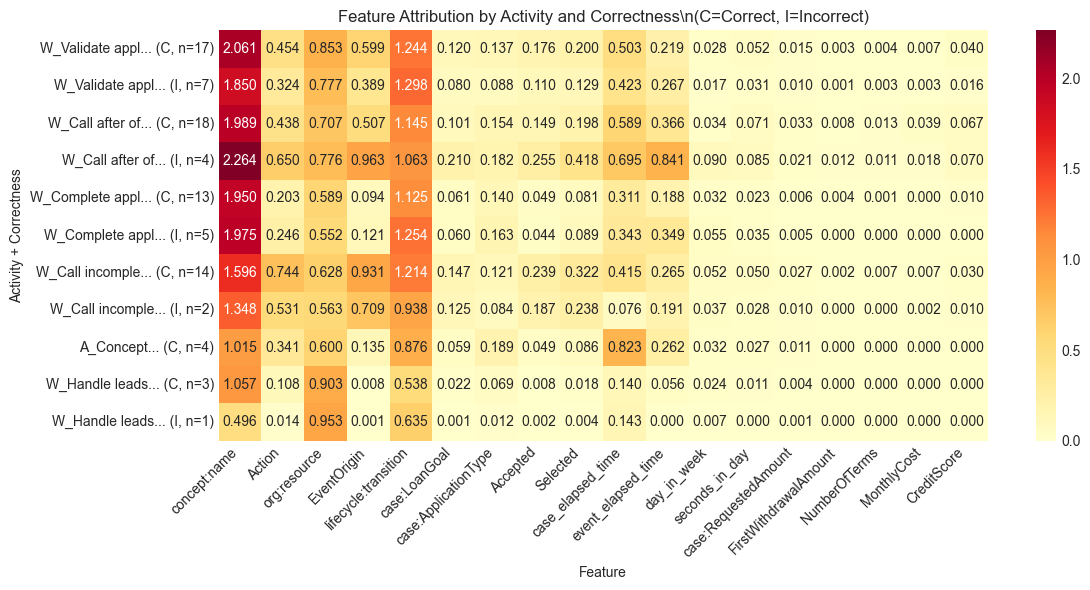

In [12]:
# Visualization 4: Heatmap of attribution by activity and correctness
top_activities = activity_stats.head(6)['Activity'].tolist()

# Build data for heatmap
heatmap_data = []
for act in top_activities:
    act_df = df[df['predicted'] == act]
    for is_correct in [True, False]:
        subset = act_df[act_df['is_correct'] == is_correct]
        if len(subset) > 0:
            row = {'Activity': act, 'Correct': is_correct, 'Count': len(subset)}
            for feat in available_features:
                row[feat] = subset[feat].mean()
            heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data)

# Create heatmap
if len(heatmap_df) > 0:
    # Create label column safely
    labels = []
    for _, r in heatmap_df.iterrows():
        act_short = str(r['Activity'])[:15]
        corr_label = 'C' if r['Correct'] else 'I'
        labels.append(f"{act_short}... ({corr_label}, n={int(r['Count'])})")
    heatmap_df['Label'] = labels
    
    fig, ax = plt.subplots(figsize=(12, max(6, len(heatmap_df) * 0.5)))
    
    pivot_data = heatmap_df.set_index('Label')[available_features]
    sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
    
    ax.set_title(f'Feature Attribution by Activity and Correctness\\n(C=Correct, I=Incorrect)')
    ax.set_xlabel('Feature')
    ax.set_ylabel('Activity + Correctness')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No data available for heatmap.")

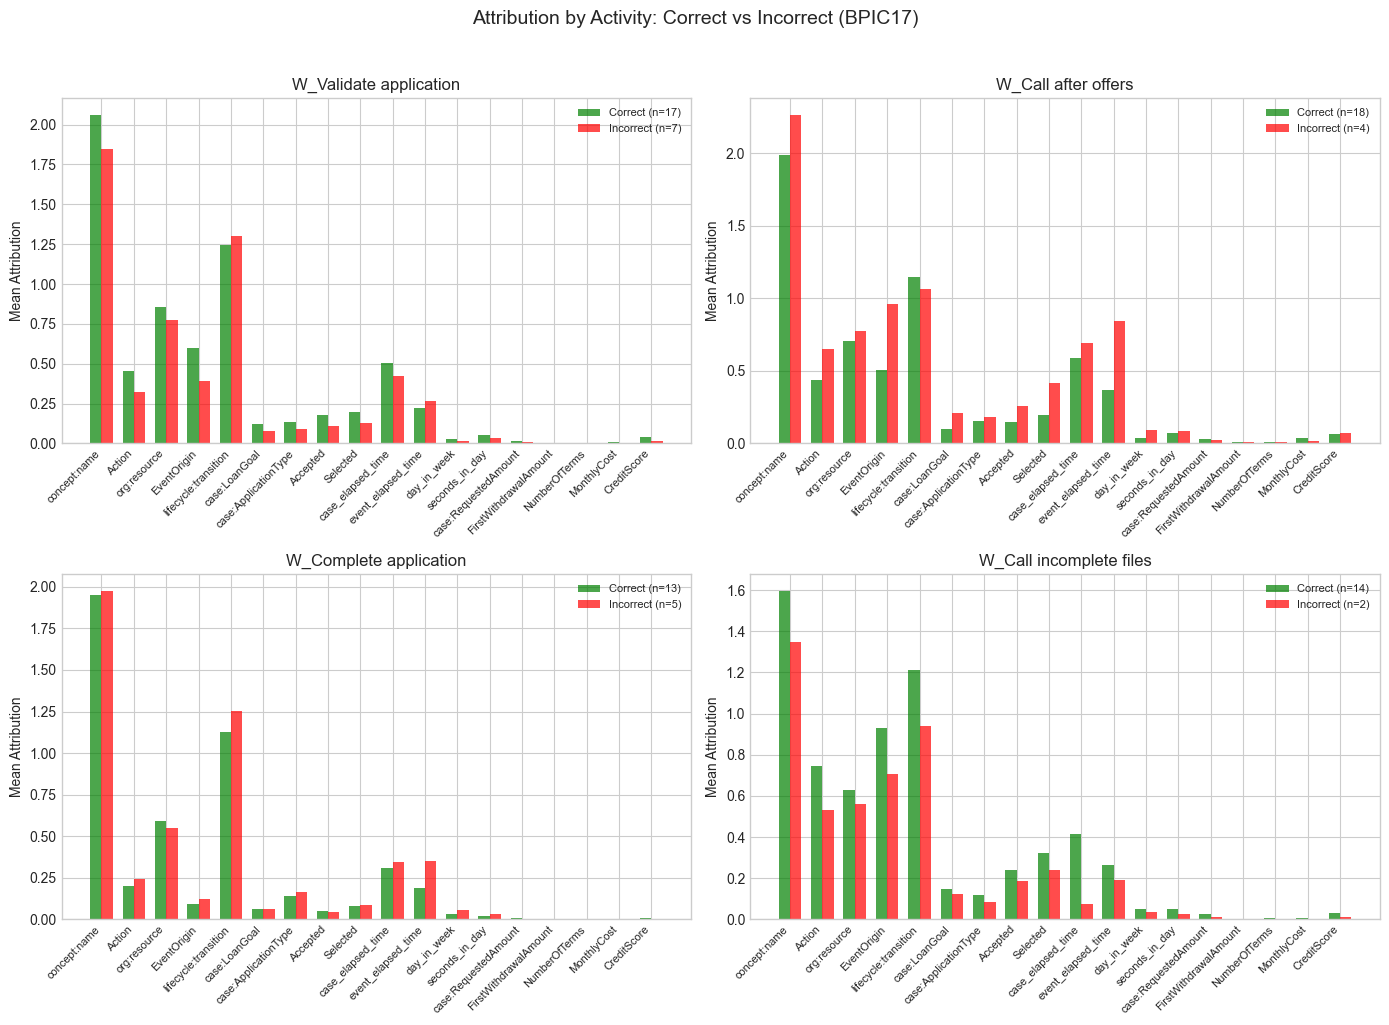

In [13]:
# Visualization 5: Grouped bar charts for each top activity
n_activities = min(4, len(top_activities))
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, act in enumerate(top_activities[:n_activities]):
    ax = axes[idx]
    act_df = df[df['predicted'] == act]
    
    act_correct = act_df[act_df['is_correct']]
    act_incorrect = act_df[~act_df['is_correct']]
    
    x = np.arange(len(available_features))
    width = 0.35
    
    correct_means = [act_correct[f].mean() if len(act_correct) > 0 else 0 for f in available_features]
    incorrect_means = [act_incorrect[f].mean() if len(act_incorrect) > 0 else 0 for f in available_features]
    
    ax.bar(x - width/2, correct_means, width, label=f'Correct (n={len(act_correct)})', color='green', alpha=0.7)
    ax.bar(x + width/2, incorrect_means, width, label=f'Incorrect (n={len(act_incorrect)})', color='red', alpha=0.7)
    
    ax.set_ylabel('Mean Attribution')
    ax.set_title(f'{act[:25]}...' if len(act) > 25 else act)
    ax.set_xticks(x)
    ax.set_xticklabels(available_features, rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=8)

# Hide unused
for idx in range(n_activities, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Attribution by Activity: Correct vs Incorrect ({CONFIG.dataset_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Confidence Analysis

In [14]:
# Compare confidence between correct and incorrect
print("Confidence Statistics:")
print(f"  Correct predictions:   mean={correct_df['confidence'].mean():.3f}, std={correct_df['confidence'].std():.3f}")
print(f"  Incorrect predictions: mean={incorrect_df['confidence'].mean():.3f}, std={incorrect_df['confidence'].std():.3f}")

if len(correct_df) > 1 and len(incorrect_df) > 1:
    t_stat, p_val = stats.ttest_ind(correct_df['confidence'], incorrect_df['confidence'])
    print(f"  T-test p-value: {p_val:.4f} {'(significant)' if p_val < 0.05 else '(not significant)'}")

Confidence Statistics:
  Correct predictions:   mean=0.715, std=0.157
  Incorrect predictions: mean=0.727, std=0.172
  T-test p-value: 0.7561 (not significant)


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_12344/2467548950.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([correct_df['confidence'].values, incorrect_df['confidence'].values],


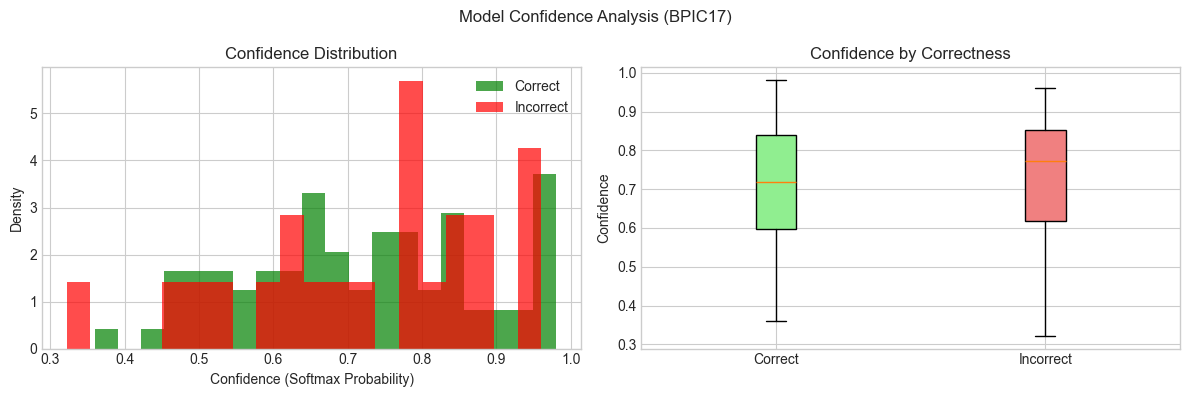

In [15]:
# Visualization 6: Confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(correct_df['confidence'], bins=20, alpha=0.7, label='Correct', color='green', density=True)
axes[0].hist(incorrect_df['confidence'], bins=20, alpha=0.7, label='Incorrect', color='red', density=True)
axes[0].set_xlabel('Confidence (Softmax Probability)')
axes[0].set_ylabel('Density')
axes[0].set_title('Confidence Distribution')
axes[0].legend()

# Box plot
bp = axes[1].boxplot([correct_df['confidence'].values, incorrect_df['confidence'].values],
                      labels=['Correct', 'Incorrect'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
axes[1].set_ylabel('Confidence')
axes[1].set_title('Confidence by Correctness')

plt.suptitle(f'Model Confidence Analysis ({CONFIG.dataset_name})', fontsize=12)
plt.tight_layout()
plt.show()

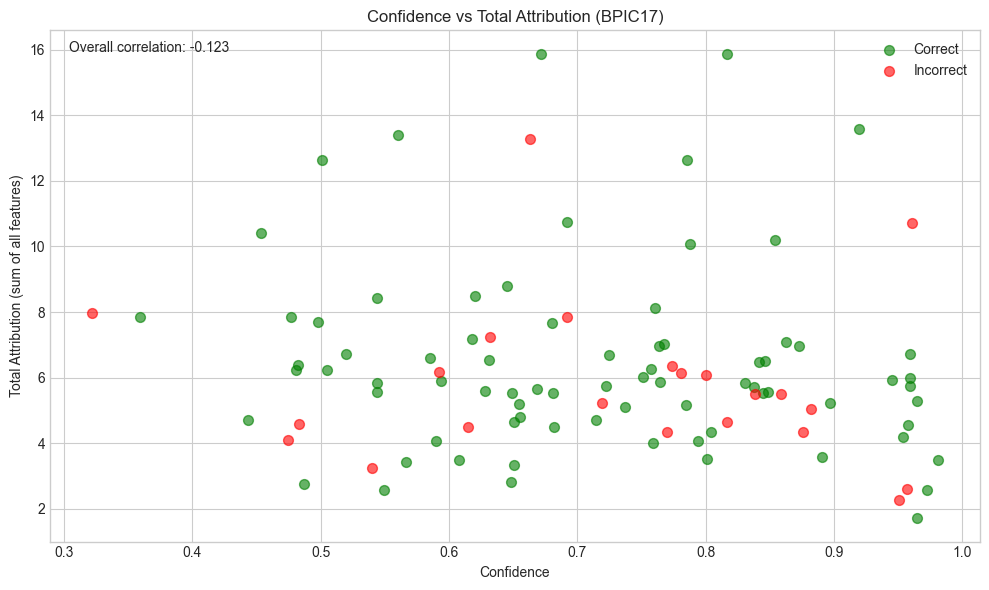

In [16]:
# Visualization 7: Confidence vs Total Attribution
df['total_attribution'] = df[available_features].sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

correct_scatter = ax.scatter(correct_df['confidence'], 
                              correct_df[available_features].sum(axis=1),
                              c='green', alpha=0.6, label='Correct', s=50)
incorrect_scatter = ax.scatter(incorrect_df['confidence'], 
                                incorrect_df[available_features].sum(axis=1),
                                c='red', alpha=0.6, label='Incorrect', s=50)

ax.set_xlabel('Confidence')
ax.set_ylabel('Total Attribution (sum of all features)')
ax.set_title(f'Confidence vs Total Attribution ({CONFIG.dataset_name})')
ax.legend()

# Add correlation
corr_all = df['confidence'].corr(df['total_attribution'])
ax.annotate(f'Overall correlation: {corr_all:.3f}', xy=(0.02, 0.98), xycoords='axes fraction',
            fontsize=10, va='top')

plt.tight_layout()
plt.show()

## 7. Error Pattern Analysis

Top Confusion Pairs (Ground Truth -> Predicted):
  A_Accepted                -> W_Complete application   : 3 times
  W_Call incomplete files   -> W_Validate application   : 3 times
  A_Cancelled               -> W_Call after offers      : 2 times
  O_Accepted                -> W_Validate application   : 2 times
  O_Sent (mail and online)  -> O_Sent                   : 2 times
  A_Concept                 -> W_Complete application   : 1 times
  A_Submitted               -> W_Handle leads           : 1 times
  O_Accepted                -> W_Call incomplete files  : 1 times
  O_Cancelled               -> W_Call after offers      : 1 times
  O_Cancelled               -> W_Validate application   : 1 times


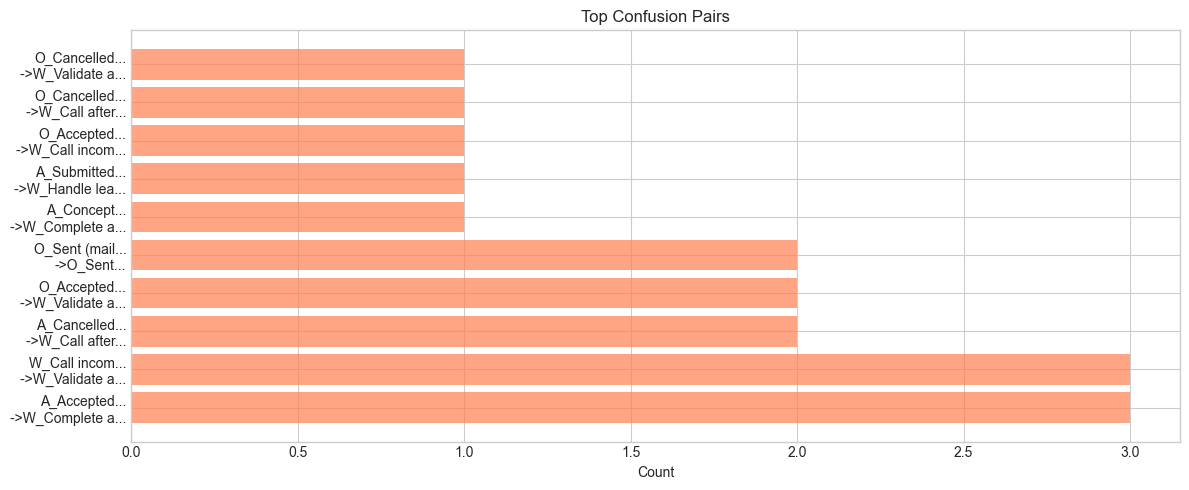

In [17]:
# Visualization 8: Confusion patterns (what gets confused with what)
if len(incorrect_df) > 0:
    confusion_pairs = incorrect_df.groupby(['ground_truth', 'predicted']).size().reset_index(name='count')
    confusion_pairs = confusion_pairs.sort_values('count', ascending=False).head(10)
    
    print("Top Confusion Pairs (Ground Truth -> Predicted):")
    for _, row in confusion_pairs.iterrows():
        print(f"  {row['ground_truth'][:25]:25s} -> {row['predicted'][:25]:25s}: {row['count']} times")
    
    # Bar chart
    fig, ax = plt.subplots(figsize=(12, 5))
    labels = [f"{r['ground_truth'][:12]}...\n->{r['predicted'][:12]}..." for _, r in confusion_pairs.iterrows()]
    ax.barh(labels, confusion_pairs['count'], color='coral', alpha=0.7)
    ax.set_xlabel('Count')
    ax.set_title('Top Confusion Pairs')
    plt.tight_layout()
    plt.show()
else:
    print("No incorrect predictions to analyze.")

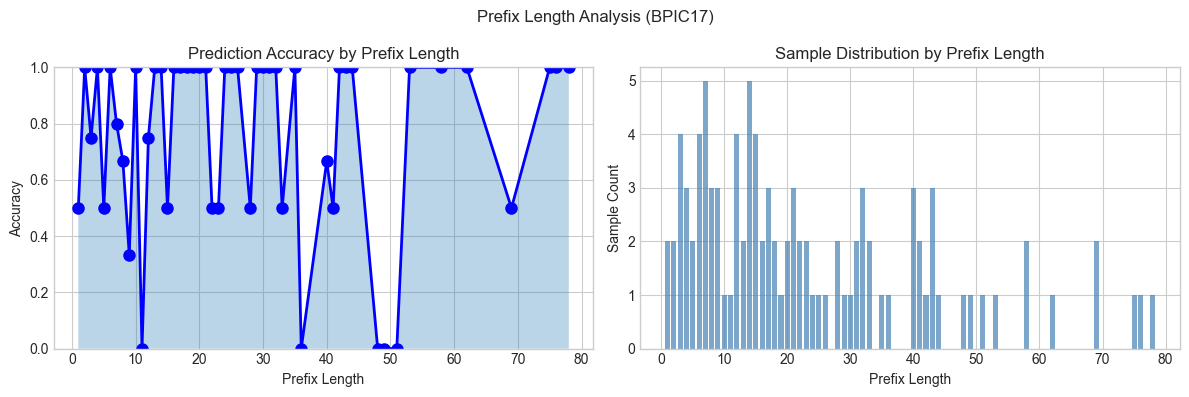

In [18]:
# Visualization 9: Accuracy by prefix length
prefix_accuracy = df.groupby('prefix_len').agg({
    'is_correct': ['sum', 'count', 'mean']
}).reset_index()
prefix_accuracy.columns = ['Prefix_Length', 'Correct', 'Total', 'Accuracy']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy by prefix length
axes[0].plot(prefix_accuracy['Prefix_Length'], prefix_accuracy['Accuracy'], 'bo-', linewidth=2, markersize=8)
axes[0].fill_between(prefix_accuracy['Prefix_Length'], 0, prefix_accuracy['Accuracy'], alpha=0.3)
axes[0].set_xlabel('Prefix Length')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Prediction Accuracy by Prefix Length')
axes[0].set_ylim(0, 1)

# Sample count
axes[1].bar(prefix_accuracy['Prefix_Length'], prefix_accuracy['Total'], color='steelblue', alpha=0.7)
axes[1].set_xlabel('Prefix Length')
axes[1].set_ylabel('Sample Count')
axes[1].set_title('Sample Distribution by Prefix Length')

plt.suptitle(f'Prefix Length Analysis ({CONFIG.dataset_name})', fontsize=12)
plt.tight_layout()
plt.show()

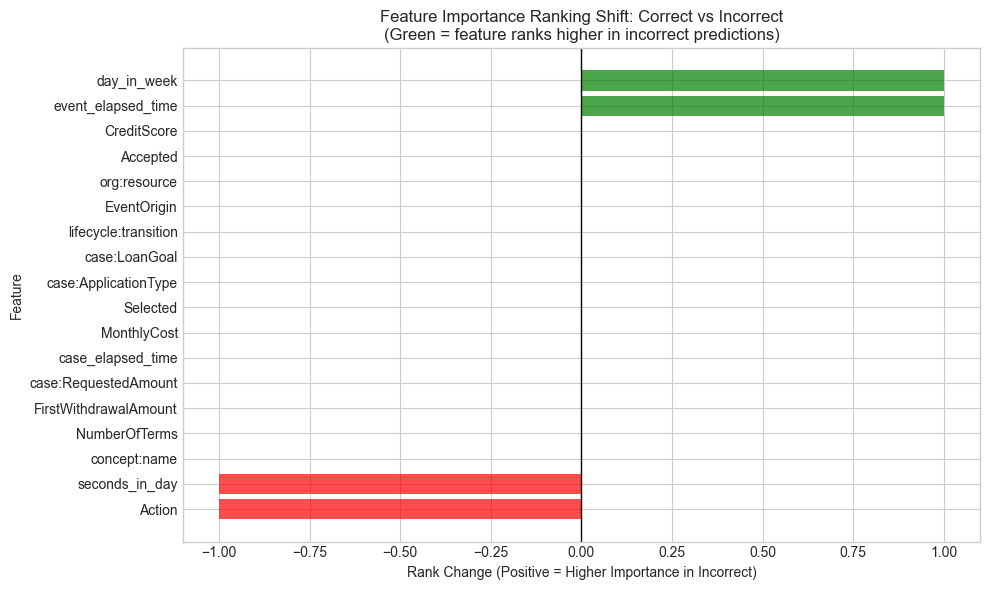


Feature Ranking Comparison:
              Feature  Correct_Rank  Incorrect_Rank  Rank_Change
               Action             6               7           -1
       seconds_in_day            12              13           -1
         concept:name             1               1            0
        NumberOfTerms            17              17            0
FirstWithdrawalAmount            18              18            0
 case:RequestedAmount            15              15            0
    case_elapsed_time             5               5            0
          MonthlyCost            16              16            0
             Selected             8               8            0
 case:ApplicationType            10              10            0
        case:LoanGoal            11              11            0
 lifecycle:transition             2               2            0
          EventOrigin             4               4            0
         org:resource             3               3          

In [19]:
# Visualization 10: Feature importance ranking shift
# Compare which features rank higher in correct vs incorrect predictions

correct_ranking = correct_df[available_features].mean().sort_values(ascending=False)
incorrect_ranking = incorrect_df[available_features].mean().sort_values(ascending=False) if len(incorrect_df) > 0 else correct_ranking

# Create ranking comparison
ranking_data = []
for feat in available_features:
    correct_rank = list(correct_ranking.index).index(feat) + 1
    incorrect_rank = list(incorrect_ranking.index).index(feat) + 1
    ranking_data.append({
        'Feature': feat,
        'Correct_Rank': correct_rank,
        'Incorrect_Rank': incorrect_rank,
        'Rank_Change': correct_rank - incorrect_rank  # Positive = more important in incorrect
    })

ranking_df = pd.DataFrame(ranking_data).sort_values('Rank_Change')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if rc > 0 else 'red' if rc < 0 else 'gray' for rc in ranking_df['Rank_Change']]
ax.barh(ranking_df['Feature'], ranking_df['Rank_Change'], color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Rank Change (Positive = Higher Importance in Incorrect)')
ax.set_ylabel('Feature')
ax.set_title('Feature Importance Ranking Shift: Correct vs Incorrect\n(Green = feature ranks higher in incorrect predictions)')

plt.tight_layout()
plt.show()

print("\nFeature Ranking Comparison:")
print(ranking_df.to_string(index=False))

## 8. Summary and Save Results

In [20]:
print("="*80)
print("SUMMARY: Attribution Analysis by Prediction Correctness")
print("="*80)

print(f"\nDataset: {CONFIG.dataset_name}")
print(f"Mode: {'TEST' if TEST_MODE else 'FULL'}")
print(f"Total samples: {len(df)}")
print(f"Correct: {len(correct_df)} ({100*len(correct_df)/len(df):.1f}%)")
print(f"Incorrect: {len(incorrect_df)} ({100*len(incorrect_df)/len(df):.1f}%)")

print(f"\n--- Key Findings ---")

# Most different features
significant_features = comparison_df[comparison_df['Significant']]['Feature'].tolist()
if significant_features:
    print(f"\nFeatures with significant attribution difference:")
    for feat in significant_features:
        row = comparison_df[comparison_df['Feature'] == feat].iloc[0]
        direction = "higher in incorrect" if row['Difference'] > 0 else "higher in correct"
        print(f"  - {feat}: {direction} (p={row['P_Value']:.4f})")
else:
    print("\nNo statistically significant differences found.")

# Confidence
print(f"\nConfidence:")
print(f"  Correct predictions: {correct_df['confidence'].mean():.3f} avg")
print(f"  Incorrect predictions: {incorrect_df['confidence'].mean():.3f} avg" if len(incorrect_df) > 0 else "  No incorrect predictions")

SUMMARY: Attribution Analysis by Prediction Correctness

Dataset: BPIC17
Mode: TEST
Total samples: 100
Correct: 78 (78.0%)
Incorrect: 22 (22.0%)

--- Key Findings ---

No statistically significant differences found.

Confidence:
  Correct predictions: 0.715 avg
  Incorrect predictions: 0.727 avg


In [21]:
# Save results
output_dir = CONFIG.get_results_dir()
mode_suffix = '_test' if TEST_MODE else '_full'
output_path = output_dir / f'attribution_by_correctness{mode_suffix}.pkl'

with open(output_path, 'wb') as f:
    pickle.dump({
        'results_df': df,
        'comparison_df': comparison_df,
        'ranking_df': ranking_df,
        'config': CONFIG.to_dict(),
        'test_mode': TEST_MODE
    }, f)

print(f"\nResults saved to: {output_path}")


Results saved to: /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src/interpretability/notebooks/results/bpic17/attribution_by_correctness_test.pkl
